# Graph Mining – Practical Assignment 2 (Complete Notebook)

This notebook is a complete solution for the practical assignment and follows the requested format:

- Clear sectioning by parts and questions
- Code, plots, and reported metrics for every item
- Short, presentation-oriented English Markdown describing what each code block does
- A result analysis block after each major step

Implementation notes:
- Large datasets (Higgs Twitter and STRING) are handled via reproducible subgraph sampling and/or score filtering for practical runtime.
- Part 5 (Newman–Girvan) is implemented manually (no built-in community detection routines are used).


## 0. Setup

We import the required libraries, set random seeds for reproducibility, and locate the dataset folder.


In [1]:
import os
import gzip
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (7, 4)


### Dataset path helper

The extracted dataset folder should contain:
- `DisGeNET/`
- `Twitter Higgs Dataset (SNAP)/`
- `STRING PPI Network/`

If the auto-detection fails, set `DATA_ROOT` manually.


In [2]:
def find_dataset_root(start: Path = None) -> Path:
    if start is None:
        start = Path.cwd()

    required = {
        "DisGeNET": ["all_gene_disease_associations.txt.gz", "curated_gene_disease_associations.txt.gz"],
        "Twitter Higgs Dataset (SNAP)": ["higgs-social_network.edgelist.gz"],
        "STRING PPI Network": ["Source.txt"],
    }

    candidates = [start] + [p for p in start.rglob("*") if p.is_dir()]

    for c in candidates:
        ok = True
        for folder, files in required.items():
            folder_path = c / folder
            if not folder_path.exists():
                ok = False
                break
            for f in files:
                if not (folder_path / f).exists():
                    ok = False
                    break
            if not ok:
                break
        if ok:
            return c

    raise FileNotFoundError(
        "Dataset root not found. Extract the ZIP and ensure folders like 'DisGeNET' and 'Twitter Higgs Dataset (SNAP)' exist near this notebook."
    )

DATA_ROOT = find_dataset_root()
DATA_ROOT


PosixPath('/Users/arshiyadoosti/Downloads/Iranidoust IUT-Graph-Mining-Course master Data Sets-Intermediate')

## Part 1 – Behavior Cascading

We implement two diffusion models on a real social network (Higgs Twitter dataset):
1. Linear Threshold Model (LTM)
2. Independent Cascade Model (ICM)

Because the full Higgs graph is large, we create a reproducible subgraph from the raw edge list.


### Part 1 – Question 1: Linear Threshold Model (threshold = 50%)

Model:
- A node becomes active if at least 50% of its neighbors are active.
- Updates are synchronous (iteration-based).
- We record the number of active nodes at each iteration and plot the growth curve.


In [3]:
HIGGS_SOCIAL_PATH = DATA_ROOT / "Twitter Higgs Dataset (SNAP)" / "higgs-social_network.edgelist.gz"

def load_higgs_subgraph(
    path: Path,
    max_edges: int = 200_000,
    max_nodes_after_lcc: int = 6_000,
    seed: int = 42,
):
    rng = random.Random(seed)

    edges = []
    with gzip.open(path, "rt", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if i >= max_edges:
                break
            u, v = line.strip().split()
            edges.append((int(u), int(v)))

    G = nx.Graph()
    G.add_edges_from(edges)

    # Keep the largest connected component
    lcc_nodes = max(nx.connected_components(G), key=len)
    G = G.subgraph(lcc_nodes).copy()

    # If still too large, take a connected BFS sample
    if G.number_of_nodes() > max_nodes_after_lcc:
        start = max(G.degree, key=lambda x: x[1])[0]
        visited = {start}
        queue = [start]
        while queue and len(visited) < max_nodes_after_lcc:
            x = queue.pop(0)
            neigh = list(G.neighbors(x))
            rng.shuffle(neigh)
            for y in neigh:
                if y not in visited:
                    visited.add(y)
                    queue.append(y)
                if len(visited) >= max_nodes_after_lcc:
                    break
        G = G.subgraph(visited).copy()

    return G

G_higgs = load_higgs_subgraph(HIGGS_SOCIAL_PATH)
G_higgs.number_of_nodes(), G_higgs.number_of_edges()


(6000, 74562)

In [4]:
def linear_threshold_diffusion(G: nx.Graph, seeds, threshold: float = 0.5, max_iter: int = 50):
    active = set(seeds)
    history = [len(active)]

    for _ in range(max_iter):
        newly_active = set()
        for v in G.nodes():
            if v in active:
                continue
            neigh = list(G.neighbors(v))
            if not neigh:
                continue
            frac_active = sum((u in active) for u in neigh) / len(neigh)
            if frac_active >= threshold:
                newly_active.add(v)

        if not newly_active:
            break

        active |= newly_active
        history.append(len(active))

    return history, active


We evaluate two seed categories:
- High-degree seeds (top-k by degree)
- Random seeds (k uniformly sampled nodes)

This directly supports reporting the final diffusion size for each category.


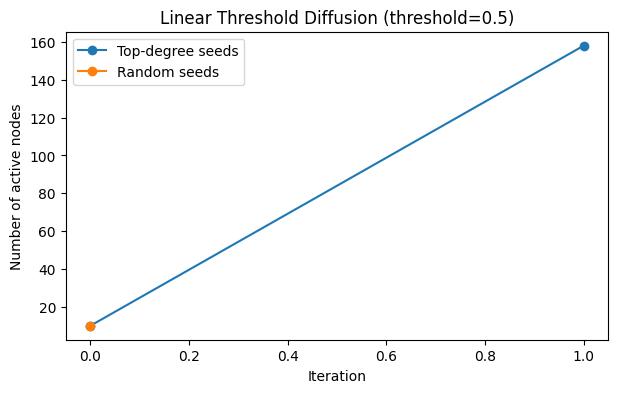

,Seed category,Number of seeds,Final active nodes
0,Top-degree seeds,10,158
1,Random seeds,10,10


In [5]:
def pick_seeds(G: nx.Graph, k: int = 10, seed: int = 42):
    rng = random.Random(seed)
    top_degree = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:k]]
    random_seeds = rng.sample(list(G.nodes()), k=k)
    return top_degree, random_seeds

seeds_top, seeds_rand = pick_seeds(G_higgs, k=10, seed=42)

history_top_05, active_top_05 = linear_threshold_diffusion(G_higgs, seeds_top, threshold=0.5)
history_rand_05, active_rand_05 = linear_threshold_diffusion(G_higgs, seeds_rand, threshold=0.5)

plt.figure()
plt.plot(history_top_05, marker="o", label="Top-degree seeds")
plt.plot(history_rand_05, marker="o", label="Random seeds")
plt.xlabel("Iteration")
plt.ylabel("Number of active nodes")
plt.title("Linear Threshold Diffusion (threshold=0.5)")
plt.legend()
plt.show()

pd.DataFrame(
    [
        ["Top-degree seeds", len(seeds_top), len(active_top_05)],
        ["Random seeds", len(seeds_rand), len(active_rand_05)],
    ],
    columns=["Seed category", "Number of seeds", "Final active nodes"],
)


#### Result analysis

- The growth curve shows how activation expands and then saturates when no more nodes satisfy the threshold rule.
- High-degree seeds typically produce faster and larger cascades than random seeds, because they expose more neighbors early.
- The table reports the final activated size for each seed category.


### Threshold sensitivity

We test multiple thresholds to check whether increasing the threshold changes diffusion speed and reach.


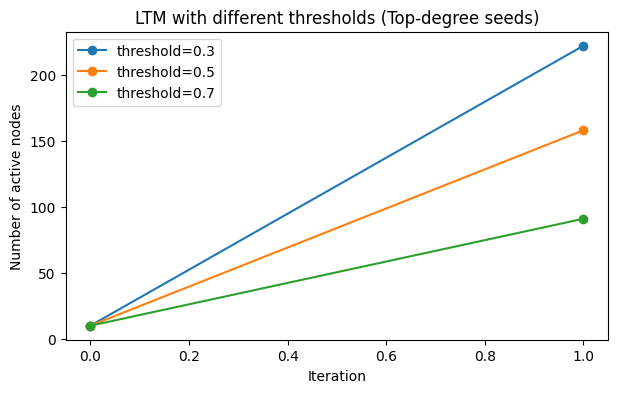

,Threshold,Final active nodes,Iterations until stop
0,0.3,222,1
1,0.5,158,1
2,0.7,91,1


In [6]:
thresholds = [0.3, 0.5, 0.7]
results_ltm = []

plt.figure()
for th in thresholds:
    h, act = linear_threshold_diffusion(G_higgs, seeds_top, threshold=th)
    results_ltm.append([th, len(act), len(h) - 1])
    plt.plot(h, marker="o", label=f"threshold={th}")

plt.xlabel("Iteration")
plt.ylabel("Number of active nodes")
plt.title("LTM with different thresholds (Top-degree seeds)")
plt.legend()
plt.show()

pd.DataFrame(results_ltm, columns=["Threshold", "Final active nodes", "Iterations until stop"])


#### Result analysis

- Higher thresholds usually reduce the final cascade size and can stop diffusion earlier.
- Iterations until stop are included to summarize diffusion speed.
- This is consistent with the idea that stricter adoption requirements reduce spread.


### Part 1 – Question 2: Independent Cascade Model (edge probability = 10%)

Model:
- Each newly activated node attempts to activate each inactive neighbor exactly once, with probability `p`.
- We run multiple random simulations, compute the final cascade size per simulation, and report the average.
- We also plot the mean growth curve.


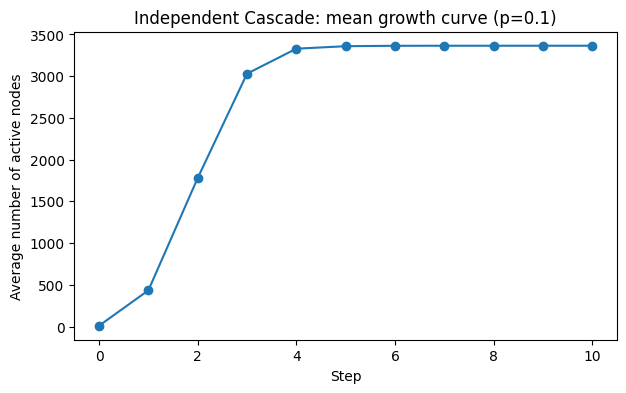

,Mean final cascade size,Std of final cascade size,Number of trials
0,3364.733333,34.965634,60


In [7]:
def independent_cascade(G: nx.Graph, seeds, p: float = 0.1, rng: random.Random = None, max_steps: int = 50):
    if rng is None:
        rng = random.Random(42)

    active = set(seeds)
    newly_active = set(seeds)
    history = [len(active)]

    for _ in range(max_steps):
        next_new = set()
        for u in newly_active:
            for v in G.neighbors(u):
                if v in active:
                    continue
                if rng.random() < p:
                    next_new.add(v)

        if not next_new:
            break

        active |= next_new
        newly_active = next_new
        history.append(len(active))

    return history, active


def run_icm_trials(G, seeds, p=0.1, n_trials=50, seed=42):
    rng = random.Random(seed)
    final_sizes = []
    histories = []

    for _ in range(n_trials):
        trial_rng = random.Random(rng.randint(0, 10**9))
        h, act = independent_cascade(G, seeds, p=p, rng=trial_rng)
        final_sizes.append(len(act))
        histories.append(h)

    max_len = max(len(h) for h in histories)
    padded = np.array([h + [h[-1]] * (max_len - len(h)) for h in histories], dtype=float)
    mean_curve = padded.mean(axis=0)

    return np.array(final_sizes), mean_curve

final_sizes_icm, mean_curve_icm = run_icm_trials(G_higgs, seeds_top, p=0.1, n_trials=60, seed=42)

plt.figure()
plt.plot(mean_curve_icm, marker="o")
plt.xlabel("Step")
plt.ylabel("Average number of active nodes")
plt.title("Independent Cascade: mean growth curve (p=0.1)")
plt.show()

pd.DataFrame(
    {
        "Mean final cascade size": [final_sizes_icm.mean()],
        "Std of final cascade size": [final_sizes_icm.std()],
        "Number of trials": [len(final_sizes_icm)],
    }
)


#### Result analysis

- ICM is stochastic, so final cascade sizes vary across trials.
- The mean and standard deviation summarize the expected reach and variability.
- Compared to LTM, ICM often grows more gradually on average, because activation can fail at every edge attempt.


### LTM vs ICM (direct comparison)

This block summarizes why the two models can behave differently on the same social graph:

- LTM is deterministic given seeds and thresholds: once enough neighbors are active, activation is guaranteed.
- ICM is probabilistic: even with many active neighbors, a node may still never activate if all attempts fail.
- LTM can show rapid early growth but may stop when local neighborhoods do not cross the threshold.
- ICM can be slower on average, but successful runs can reach farther because activation does not require a majority of neighbors.


## Part 2 – Power Laws and Preferential Attachment

We analyze heavy-tailed degree distributions via:
1. A Barabási–Albert (BA) preferential attachment graph
2. The real DisGeNET gene–disease network


In [11]:
def powerlaw_exponent_ccdf(deg, kmin=5):
    deg = np.asarray(deg)
    deg = deg[deg >= 1]

    k_values = np.sort(np.unique(deg))
    ccdf = np.array([(deg >= k).mean() for k in k_values])

    mask = k_values >= kmin
    x = np.log10(k_values[mask])
    y = np.log10(ccdf[mask] + 1e-12)

    slope, intercept = np.polyfit(x, y, 1)

    # CCDF: P(K >= k) ~ k^{-(gamma-1)}  => gamma = 1 - slope
    gamma = 1 - slope
    return gamma, (k_values, ccdf), (slope, intercept)


### Part 2 – Question 1: Barabási–Albert graph (n=5000, m=3)

We generate a BA graph, plot the degree distribution on log-log axes, and fit a line in log space to estimate a power-law exponent.


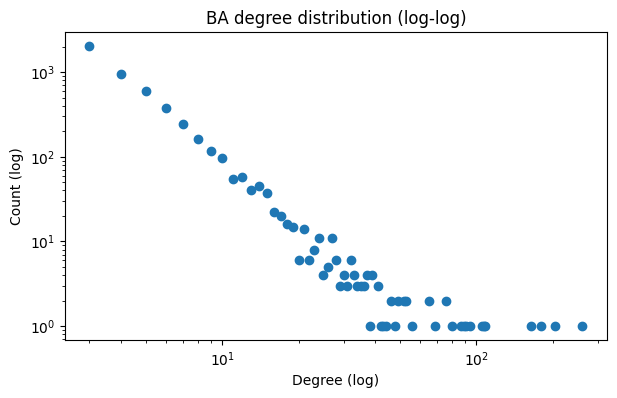

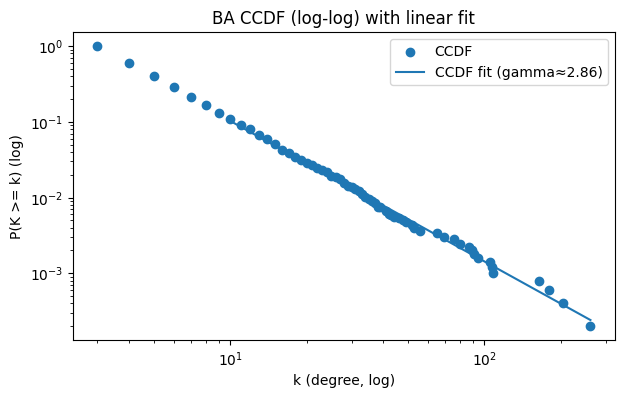

2.8563965581581536

In [12]:
G_ba = nx.barabasi_albert_graph(5000, 3, seed=42)
deg_ba = np.array([d for _, d in G_ba.degree()])

vals_ba, counts_ba = np.unique(deg_ba, return_counts=True)

plt.figure()
plt.scatter(vals_ba, counts_ba)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Count (log)")
plt.title("BA degree distribution (log-log)")
plt.show()

gamma_ba, (k_ba, ccdf_ba), (slope_ba, intercept_ba) = powerlaw_exponent_ccdf(deg_ba, kmin=10)

plt.figure()
plt.scatter(k_ba, ccdf_ba, label="CCDF")
x_line = np.linspace(np.log10(k_ba[k_ba >= 10].min()), np.log10(k_ba.max()), 100)
y_line = slope_ba * x_line + intercept_ba
plt.plot(10**x_line, 10**y_line, label=f"CCDF fit (gamma≈{gamma_ba:.2f})")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("k (degree, log)")
plt.ylabel("P(K >= k) (log)")
plt.title("BA CCDF (log-log) with linear fit")
plt.legend()
plt.show()

gamma_ba


#### Result analysis

- The log-log plot is close to linear over a wide degree range, indicating power-law-like behavior.
- The fitted exponent (printed above) is the requested estimate for this BA graph.
- Deviations at very small and very large degrees are expected due to finite-size and discrete-degree effects.


### Part 2 – Question 2: DisGeNET (gene–disease network)

We build a bipartite graph from DisGeNET associations, compute degree distributions, and test power-law compatibility via a log-log plot and a simple linear fit.


In [13]:
DISGENET_ALL_PATH = DATA_ROOT / "DisGeNET" / "all_gene_disease_associations.txt.gz"

def load_disgenet_all(path: Path):
    cols = [
        "geneId","geneSymbol","geneName",
        "diseaseId","diseaseName",
        "score","NumberOfPubmeds","associationType","source"
    ]
    df = pd.read_csv(path, sep="\t", header=None, names=cols, compression="gzip", low_memory=False)
    df = df[df["geneId"] != "geneId"].copy()
    return df

df_dis = load_disgenet_all(DISGENET_ALL_PATH)
df_dis.shape


(429111, 9)

In [14]:
G_dis = nx.Graph()

for row in df_dis.itertuples(index=False):
    g = f"G:{row.geneSymbol}"
    d = f"D:{row.diseaseId}"
    G_dis.add_edge(g, d)

G_dis.number_of_nodes(), G_dis.number_of_edges()


(31794, 429081)

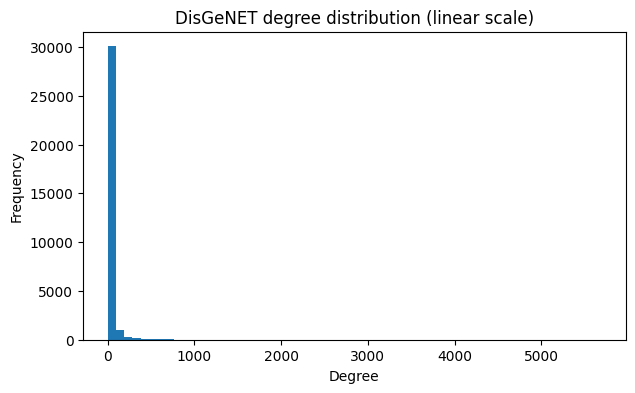

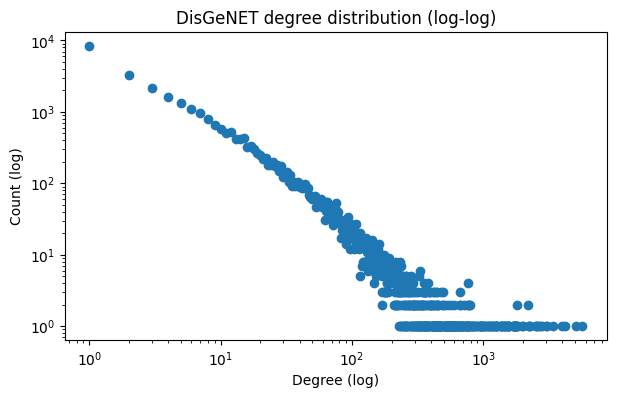

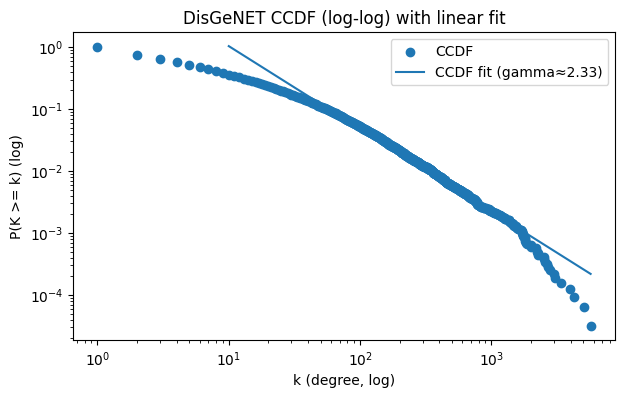

2.3342234706201177

In [15]:
deg_dis = np.array([d for _, d in G_dis.degree()])

plt.figure()
plt.hist(deg_dis, bins=60)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("DisGeNET degree distribution (linear scale)")
plt.show()

vals_dis, counts_dis = np.unique(deg_dis, return_counts=True)

plt.figure()
plt.scatter(vals_dis, counts_dis)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Count (log)")
plt.title("DisGeNET degree distribution (log-log)")
plt.show()

gamma_dis, (k_dis, ccdf_dis), (slope_dis, intercept_dis) = powerlaw_exponent_ccdf(deg_dis, kmin=10)

plt.figure()
plt.scatter(k_dis, ccdf_dis, label="CCDF")
x_line = np.linspace(np.log10(k_dis[k_dis >= 10].min()), np.log10(k_dis.max()), 100)
y_line = slope_dis * x_line + intercept_dis
plt.plot(10**x_line, 10**y_line, label=f"CCDF fit (gamma≈{gamma_dis:.2f})")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("k (degree, log)")
plt.ylabel("P(K >= k) (log)")
plt.title("DisGeNET CCDF (log-log) with linear fit")
plt.legend()
plt.show()

gamma_dis


#### Result analysis

- DisGeNET is a real bipartite graph; its degree distribution can be heavy-tailed but may deviate from an ideal power law.
- The fitted exponent provides a comparable summary, but the mechanism is not pure preferential attachment.
- Differences between BA and DisGeNET exponents can be explained by curation, biomedical heterogeneity, and publication bias.


## Part 3 – Random Walk (PageRank and Random Walk with Restart)

We compute:
1. PageRank on the STRING PPI network
2. Random Walk with Restart (RWR) from a chosen seed protein

Data policy:
- If a local STRING file is available, it will be used.
- Otherwise, the notebook downloads the human physical PPI network from STRING.


### Part 3 – Data loading (STRING PPI)

We use high-confidence physical interactions via a score threshold.
This reduces noise and keeps computations practical.


In [16]:
# A local cache folder next to the notebook (safe to write)
CACHE_DIR = Path.cwd() / "_cache_string"
CACHE_DIR.mkdir(exist_ok=True)

STRING_LINKS_URL = "https://stringdb-downloads.org/download/protein.physical.links.v12.0/9606.protein.physical.links.v12.0.txt.gz"
STRING_INFO_URL  = "https://stringdb-downloads.org/download/protein.info.v12.0/9606.protein.info.v12.0.txt.gz"

links_gz_path = CACHE_DIR / "9606.protein.physical.links.v12.0.txt.gz"
info_gz_path  = CACHE_DIR / "9606.protein.info.v12.0.txt.gz"

def download_if_missing(url: str, path: Path):
    if path.exists():
        return True
    try:
        import urllib.request
        print(f"Downloading: {url}")
        urllib.request.urlretrieve(url, path)
        return True
    except Exception as e:
        print("Download failed:", e)
        print("If you are offline, download the file manually and place it here:", path)
        return False

ok1 = download_if_missing(STRING_LINKS_URL, links_gz_path)
ok2 = download_if_missing(STRING_INFO_URL, info_gz_path)

ok1, ok2, links_gz_path.exists(), info_gz_path.exists()


(True, True, True, True)

In [17]:
def load_string_ppi_graph(links_path: Path, info_path: Path = None, score_threshold: int = 700, max_edges: int = None):
    if not links_path.exists():
        raise FileNotFoundError("STRING links file not found. Download it or place it in the cache folder.")

    # Optional mapping from STRING protein id to preferred name
    id_to_name = {}
    if info_path is not None and info_path.exists():
        with gzip.open(info_path, "rt", encoding="utf-8", errors="ignore") as f:
            _ = f.readline()
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) >= 2:
                    pid, pname = parts[0], parts[1]
                    id_to_name[pid] = pname

    G = nx.Graph()
    kept = 0
    with gzip.open(links_path, "rt", encoding="utf-8", errors="ignore") as f:
        _ = f.readline()
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            p1, p2, score = parts[0], parts[1], int(parts[2])
            if score < score_threshold:
                continue

            n1 = id_to_name.get(p1, p1)
            n2 = id_to_name.get(p2, p2)
            w = score / 1000.0

            G.add_edge(n1, n2, weight=w, score=score)

            kept += 1
            if max_edges is not None and kept >= max_edges:
                break

    if G.number_of_nodes() > 0:
        lcc = max(nx.connected_components(G), key=len)
        G = G.subgraph(lcc).copy()

    return G

G_ppi = load_string_ppi_graph(links_gz_path, info_gz_path, score_threshold=700)
G_ppi.number_of_nodes(), G_ppi.number_of_edges()


(9830, 85576)

### Part 3 – Question 1: PageRank

We compute PageRank scores and report the top 5 proteins.  
We also compare PageRank to degree to check whether top PageRank nodes are hubs.


In [18]:
pr = nx.pagerank(G_ppi, alpha=0.85, weight="weight")
top5_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:5]

top5_table = [(node, score, G_ppi.degree(node)) for node, score in top5_pr]
pd.DataFrame(top5_table, columns=["Node", "PageRank", "Degree"])


,Node,PageRank,Degree
0,GNB1,0.001851,190
1,GNG2,0.001513,163
2,RPS27A,0.001472,434
3,TP53,0.001436,232
4,UBC,0.001359,279


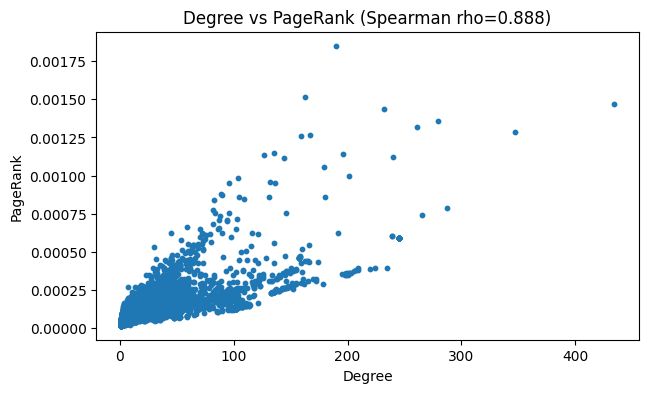

0.8880893338061184

In [19]:
def spearman_corr(x: np.ndarray, y: np.ndarray) -> float:
    # Spearman correlation = Pearson correlation of ranks
    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    rx = rx - rx.mean()
    ry = ry - ry.mean()
    denom = np.sqrt((rx**2).sum()) * np.sqrt((ry**2).sum())
    if denom == 0:
        return float("nan")
    return float((rx * ry).sum() / denom)

deg = np.array([G_ppi.degree(n) for n in G_ppi.nodes()])
pr_vals = np.array([pr[n] for n in G_ppi.nodes()])

rho = spearman_corr(deg, pr_vals)

plt.figure()
plt.scatter(deg, pr_vals, s=10)
plt.xlabel("Degree")
plt.ylabel("PageRank")
plt.title(f"Degree vs PageRank (Spearman rho={rho:.3f})")
plt.show()

rho


#### Result analysis

- The top-5 PageRank nodes are reported in the table above with their degrees.
- A positive degree–PageRank correlation is expected in many PPI networks, but PageRank can also emphasize connectors between submodules.
- The Spearman correlation value summarizes the monotonic relationship between degree and PageRank.


### Part 3 – Question 2: Random Walk with Restart (RWR)

We implement RWR using power iteration:

p_{t+1} = (1-r) * P^T p_t + r * p0

where:
- r is the restart probability
- p0 is a one-hot distribution on the seed


In [20]:
def rwr_power_iteration(G: nx.Graph, seed_node, restart_prob: float = 0.15, max_iter: int = 200, tol: float = 1e-10, weight: str = "weight"):
    nodes = list(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    n = len(nodes)

    neigh_info = []
    for u in nodes:
        neigh = []
        total_w = 0.0
        for v, attr in G[u].items():
            w = float(attr.get(weight, 1.0))
            neigh.append((v, w))
            total_w += w
        neigh_info.append((neigh, total_w))

    p = np.zeros(n, dtype=float)
    p0 = np.zeros(n, dtype=float)
    p0[idx[seed_node]] = 1.0
    p[:] = p0

    for _ in range(max_iter):
        p_new = np.zeros(n, dtype=float)

        for u in nodes:
            i = idx[u]
            neigh, total_w = neigh_info[i]
            if total_w == 0:
                continue
            share = (1 - restart_prob) * p[i]
            for v, w in neigh:
                j = idx[v]
                p_new[j] += share * (w / total_w)

        p_new += restart_prob * p0

        if np.linalg.norm(p_new - p, 1) < tol:
            p = p_new
            break
        p = p_new

    return {nodes[i]: float(p[i]) for i in range(n)}

seed_ppi = max(G_ppi.degree, key=lambda x: x[1])[0]
seed_ppi


'RPS27A'

In [21]:
scores_rwr = rwr_power_iteration(G_ppi, seed_ppi, restart_prob=0.15)

ranked = sorted(scores_rwr.items(), key=lambda x: x[1], reverse=True)
top_similar = [(n, s, G_ppi.degree(n)) for n, s in ranked if n != seed_ppi][:5]

pd.DataFrame(top_similar, columns=["Node", "RWR score", "Degree"])


,Node,RWR score,Degree
0,UBA52,0.007826,347
1,UBC,0.006957,279
2,UBB,0.006432,240
3,RPS7,0.003182,209
4,RPS6,0.003178,209


#### Result analysis

- The top nodes by RWR score form the most seed-proximal region under repeated restarts.
- These nodes often share neighborhoods with the seed, reflecting potential functional or physical proximity in a PPI network.
- RWR is seed-centric, while PageRank is global.


### Restart probability sensitivity

We compare top-20 overlap for different restart probabilities to show how locality changes as r increases.


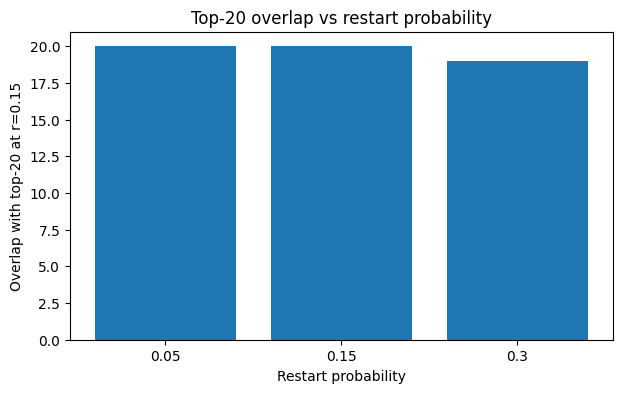

{0.05: 20, 0.15: 20, 0.3: 19}

In [22]:
restart_values = [0.05, 0.15, 0.30]
top20_sets = {}

for r in restart_values:
    sc = rwr_power_iteration(G_ppi, seed_ppi, restart_prob=r)
    top20 = [n for n, _ in sorted(sc.items(), key=lambda x: x[1], reverse=True) if n != seed_ppi][:20]
    top20_sets[r] = set(top20)

ref = top20_sets[0.15]
overlaps = {r: len(ref & top20_sets[r]) for r in restart_values}

plt.figure()
plt.bar([str(r) for r in restart_values], [overlaps[r] for r in restart_values])
plt.xlabel("Restart probability")
plt.ylabel("Overlap with top-20 at r=0.15")
plt.title("Top-20 overlap vs restart probability")
plt.show()

overlaps


#### Result analysis

- Smaller restart probabilities produce more global rankings (the walk explores further).
- Larger restart probabilities focus on a tighter neighborhood around the seed.
- The overlap values quantify how much the ranking changes when r changes.


## Part 4 – Strength of Weak Ties and Community Structure

We analyze weak ties in a DisGeNET-derived gene network.

Since DisGeNET is bipartite (genes–diseases), we create a gene–gene projection:
- Two genes are linked if they share at least one disease.
- Edge weight is the Jaccard similarity between their disease sets.

This yields a unipartite graph suitable for tie-strength and community analysis.


### Part 4 – Question 1: Weak ties and community boundaries

Pipeline:
1. Load curated DisGeNET data
2. Build gene disease-sets
3. Build a gene–gene projection with Jaccard weights
4. Detect communities (greedy modularity)
5. Compare how often weak edges fall between communities


In [23]:
DISGENET_CURATED_PATH = DATA_ROOT / "DisGeNET" / "curated_gene_disease_associations.txt.gz"

df_cur = pd.read_csv(
    DISGENET_CURATED_PATH,
    sep="\t",
    header=None,
    names=[
        "geneId","geneSymbol","geneName",
        "diseaseId","diseaseName",
        "score","NumberOfPubmeds","associationType","source"
    ],
    compression="gzip",
    low_memory=False,
)
df_cur = df_cur[df_cur["geneId"] != "geneId"].copy()
df_cur = df_cur[["geneSymbol", "diseaseId"]].dropna()
df_cur.shape


(26522, 2)

In [24]:
gene_to_diseases = df_cur.groupby("geneSymbol")["diseaseId"].apply(set).to_dict()
disease_to_genes = df_cur.groupby("diseaseId")["geneSymbol"].apply(list).to_dict()

from collections import defaultdict

pair_shared = defaultdict(int)

CAP_GENES_PER_DISEASE = 200
rng = random.Random(42)

for dis, genes in disease_to_genes.items():
    if len(genes) > CAP_GENES_PER_DISEASE:
        genes = rng.sample(genes, CAP_GENES_PER_DISEASE)
    genes = sorted(set(genes))
    for i in range(len(genes)):
        for j in range(i + 1, len(genes)):
            pair_shared[(genes[i], genes[j])] += 1

len(pair_shared)


558381

In [25]:
G_gene = nx.Graph()

for (g1, g2), inter in pair_shared.items():
    d1 = gene_to_diseases[g1]
    d2 = gene_to_diseases[g2]
    union = len(d1) + len(d2) - inter
    if union <= 0:
        continue
    jac = inter / union
    G_gene.add_edge(g1, g2, weight=jac, shared=inter)

lcc = max(nx.connected_components(G_gene), key=len)
G_gene = G_gene.subgraph(lcc).copy()

G_gene.number_of_nodes(), G_gene.number_of_edges()


(6023, 558312)

In [26]:
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity

communities = list(greedy_modularity_communities(G_gene, weight="weight"))
node_to_comm = {}
for i, c in enumerate(communities):
    for n in c:
        node_to_comm[n] = i

mod0 = modularity(G_gene, communities, weight="weight")
len(communities), mod0


(48, 0.5601561816313164)

In [27]:
weights = np.array([G_gene[u][v]["weight"] for u, v in G_gene.edges()])
q_weak = np.quantile(weights, 0.01)
q_strong = np.quantile(weights, 0.99)

weak_edges = [(u, v) for u, v in G_gene.edges() if G_gene[u][v]["weight"] <= q_weak]
strong_edges = [(u, v) for u, v in G_gene.edges() if G_gene[u][v]["weight"] >= q_strong]

def inter_fraction(edge_list):
    if not edge_list:
        return float("nan")
    inter = 0
    for u, v in edge_list:
        if node_to_comm[u] != node_to_comm[v]:
            inter += 1
    return inter / len(edge_list)

all_edges = list(G_gene.edges())
frac_all = inter_fraction(all_edges)
frac_weak = inter_fraction(weak_edges)
frac_strong = inter_fraction(strong_edges)

pd.DataFrame(
    [
        ["All edges", len(all_edges), frac_all],
        ["Weak ties (bottom 1%)", len(weak_edges), frac_weak],
        ["Strong ties (top 1%)", len(strong_edges), frac_strong],
    ],
    columns=["Edge set", "Count", "Fraction inter-community"],
)


,Edge set,Count,Fraction inter-community
0,All edges,558312,0.396660
1,Weak ties (bottom 1%),5754,0.505388
2,Strong ties (top 1%),25710,0.000000


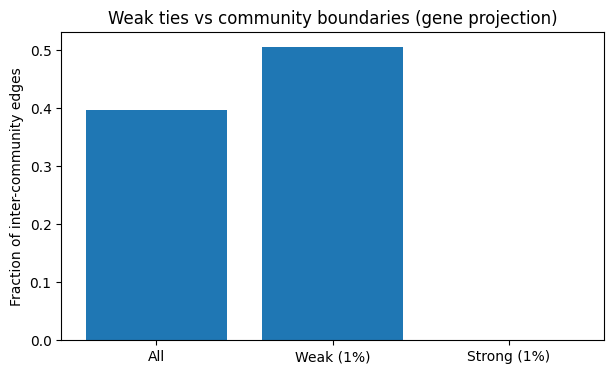

In [28]:
plt.figure()
plt.bar(["All", "Weak (1%)", "Strong (1%)"], [frac_all, frac_weak, frac_strong])
plt.ylabel("Fraction of inter-community edges")
plt.title("Weak ties vs community boundaries (gene projection)")
plt.show()


#### Result analysis

- Weak ties are edges with the smallest Jaccard similarity, meaning their endpoints share relatively few diseases.
- If weak ties have a higher inter-community fraction than the baseline, it supports the bridging role of weak ties.
- Strong ties are expected to be more often intra-community, since they connect highly similar neighborhoods.


### Part 4 – Question 2: Effect of removing weak ties

We remove weak ties and recompute:
- Number of communities
- Modularity
- Connectivity and distance-based summaries (approximated on the largest connected component)


In [29]:
G_gene_removed = G_gene.copy()
G_gene_removed.remove_edges_from(weak_edges)

communities2 = list(greedy_modularity_communities(G_gene_removed, weight="weight"))
mod2 = modularity(G_gene_removed, communities2, weight="weight")

ncc_before = nx.number_connected_components(G_gene)
ncc_after = nx.number_connected_components(G_gene_removed)

len(communities2), mod2, ncc_before, ncc_after


(46, 0.5622194992378919, 1, 1)

In [30]:
def approx_graph_distances(G: nx.Graph, sample_size: int = 200, seed: int = 42):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    if len(nodes) == 0:
        return {"avg_dist": float("nan"), "approx_diameter": float("nan")}

    sample = nodes if len(nodes) <= sample_size else rng.sample(nodes, sample_size)

    dists = []
    approx_diam = 0

    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        vals = list(lengths.values())
        if vals:
            approx_diam = max(approx_diam, max(vals))
            dists.extend(vals)

    avg_dist = float(np.mean(dists)) if dists else float("nan")
    return {"avg_dist": avg_dist, "approx_diameter": approx_diam}

lcc1 = G_gene.subgraph(max(nx.connected_components(G_gene), key=len)).copy()
lcc2 = G_gene_removed.subgraph(max(nx.connected_components(G_gene_removed), key=len)).copy()

stats1 = approx_graph_distances(lcc1, sample_size=200, seed=42)
stats2 = approx_graph_distances(lcc2, sample_size=200, seed=42)

summary = pd.DataFrame(
    [
        ["Original", lcc1.number_of_nodes(), lcc1.number_of_edges(), len(communities), mod0, ncc_before, stats1["avg_dist"], stats1["approx_diameter"]],
        ["After weak-tie removal", lcc2.number_of_nodes(), lcc2.number_of_edges(), len(communities2), mod2, ncc_after, stats2["avg_dist"], stats2["approx_diameter"]],
    ],
    columns=["Graph", "Nodes(LCC)", "Edges(LCC)", "Communities", "Modularity", "Connected components", "Approx avg dist", "Approx diameter"],
)
summary


,Graph,Nodes(LCC),Edges(LCC),Communities,Modularity,Connected components,Approx avg dist,Approx diameter
0,Original,6023,558312,48,0.560156,1,2.276833,7
1,After weak-tie removal,6023,552558,46,0.562219,1,2.291689,7


#### Result analysis

- Removing weak ties typically increases separation between communities and can increase modularity.
- The number of connected components may increase, because weak ties often act as bridges.
- Approximate distance measures can increase after bridge removal, consistent with reduced inter-community connectivity.


## Part 5 – Community Detection (Newman–Girvan) on Karate Club

Requirement:
- Implement Newman–Girvan without using existing community detection code.

We manually implement:
- Edge betweenness centrality (Brandes algorithm)
- Iterative removal of the max-betweenness edge
- Community tracking via connected components (manual BFS)
- Modularity computation (manual)
- A dendrogram showing the sequence of splits


### Part 5 – Manual graph utilities


In [31]:
def karate_adjacency():
    G = nx.karate_club_graph()
    adj = {u: set() for u in G.nodes()}
    for u, v in G.edges():
        adj[u].add(v)
        adj[v].add(u)
    return adj

def copy_adj(adj):
    return {u: set(neigh) for u, neigh in adj.items()}

def connected_components_adj(adj):
    seen = set()
    comps = []
    for start in adj:
        if start in seen:
            continue
        stack = [start]
        comp = set()
        seen.add(start)
        while stack:
            u = stack.pop()
            comp.add(u)
            for v in adj[u]:
                if v not in seen:
                    seen.add(v)
                    stack.append(v)
        comps.append(comp)
    return comps

adj0 = karate_adjacency()
len(adj0), sum(len(v) for v in adj0.values()) // 2


(34, 78)

In [32]:
def edge_betweenness_brandes(adj):
    bet = {}
    for u in adj:
        for v in adj[u]:
            if u < v:
                bet[(u, v)] = 0.0

    nodes = list(adj.keys())

    for s in nodes:
        stack = []
        pred = {w: [] for w in nodes}
        sigma = {w: 0 for w in nodes}
        dist = {w: -1 for w in nodes}

        sigma[s] = 1
        dist[s] = 0

        queue = [s]
        q_head = 0

        while q_head < len(queue):
            v = queue[q_head]
            q_head += 1
            stack.append(v)
            for w in adj[v]:
                if dist[w] < 0:
                    queue.append(w)
                    dist[w] = dist[v] + 1
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    pred[w].append(v)

        delta = {w: 0.0 for w in nodes}
        while stack:
            w = stack.pop()
            for v in pred[w]:
                if sigma[w] == 0:
                    continue
                c = (sigma[v] / sigma[w]) * (1.0 + delta[w])
                e = (v, w) if v < w else (w, v)
                bet[e] += c
                delta[v] += c

    for e in bet:
        bet[e] /= 2.0

    return bet


In [33]:
def modularity_manual(adj, communities):
    m = sum(len(adj[u]) for u in adj) / 2.0
    if m == 0:
        return 0.0

    deg = {u: len(adj[u]) for u in adj}

    Q = 0.0
    for c in communities:
        c_set = set(c)
        l_c = 0.0
        d_c = 0.0
        for u in c_set:
            d_c += deg[u]
            for v in adj[u]:
                if v in c_set:
                    l_c += 1.0
        l_c /= 2.0

        Q += (l_c / m) - (d_c / (2.0 * m)) ** 2

    return Q


### Part 5 – Newman–Girvan iterative removal

At each step:
1. Compute edge betweenness
2. Remove the edge with maximum betweenness (deterministic tie-break)
3. Record connected components and modularity

We also explicitly report:
- The edge removed at each step
- The number of communities after each removal


In [34]:
def remove_edge(adj, e):
    u, v = e
    adj[u].remove(v)
    adj[v].remove(u)

adj = copy_adj(adj0)

history = []
partitions = []

max_steps = 80  # Karate club has 78 edges
for step in range(max_steps):
    comps = connected_components_adj(adj)
    Q = modularity_manual(adj0, comps)
    partitions.append(comps)

    rec = {"step": step, "num_comms": len(comps), "modularity": Q}

    if sum(len(adj[u]) for u in adj) == 0:
        history.append(rec)
        break

    bet = edge_betweenness_brandes(adj)
    max_b = max(bet.values())
    candidates = sorted([e for e, b in bet.items() if abs(b - max_b) < 1e-12])
    e_star = candidates[0]

    rec["removed_edge"] = e_star
    rec["max_betweenness"] = max_b

    history.append(rec)
    remove_edge(adj, e_star)

df_ng = pd.DataFrame(history)
df_ng.head(15)


,step,num_comms,modularity,removed_edge,max_betweenness
0,0,1,0.000000,"(0, 31)",71.392857
1,1,1,0.000000,"(0, 2)",66.895177
2,2,1,0.000000,"(0, 8)",77.317399
3,3,1,0.000000,"(13, 33)",82.002906
4,4,1,0.000000,"(19, 33)",123.232917
5,5,1,0.000000,"(2, 32)",100.205556
6,6,1,0.000000,"(1, 30)",143.626984
7,7,1,0.000000,"(1, 2)",109.250000
8,8,1,0.000000,"(2, 3)",107.666667
9,9,1,0.000000,"(2, 7)",142.750000


In [35]:
# Steps where the number of communities increases (actual split points)
splits = df_ng[df_ng["num_comms"].diff().fillna(0) > 0][["step", "removed_edge", "num_comms", "modularity"]]
splits.head(20)


,step,removed_edge,num_comms,modularity
11,11,"(9, 33)",2,0.359961
14,14,"(0, 5)",3,0.348784
18,18,"(31, 33)",4,0.363248
24,24,"(0, 11)",5,0.401298
25,25,"(26, 33)",6,0.392505
27,27,"(0, 12)",7,0.376233
29,29,"(14, 32)",8,0.358317
31,31,"(15, 32)",9,0.341716
33,33,"(24, 27)",10,0.324786
35,35,"(18, 32)",11,0.315911


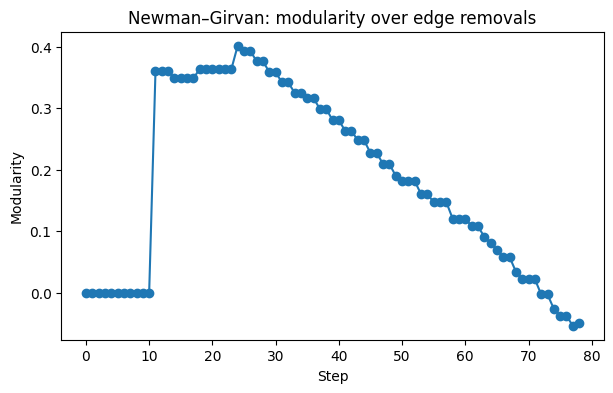

(24, 0.40129848783694944, 5)

In [36]:
plt.figure()
plt.plot(df_ng["step"], df_ng["modularity"], marker="o")
plt.xlabel("Step")
plt.ylabel("Modularity")
plt.title("Newman–Girvan: modularity over edge removals")
plt.show()

best_idx = int(df_ng["modularity"].idxmax())
best_step = int(df_ng.loc[best_idx, "step"])
best_Q = float(df_ng.loc[best_idx, "modularity"])
best_num = int(df_ng.loc[best_idx, "num_comms"])

best_step, best_Q, best_num


#### Result analysis

- The table above lists the split points: steps where the removal increases the number of connected components.
- Modularity typically increases as bridging edges are removed, then decreases after over-fragmentation.
- The final partition is selected as the step with maximum modularity (reported above).


### Dendrogram construction

We build a binary split tree from the sequence of partitions.
Each time a component splits into two components after an edge removal, we create a branching event.


In [37]:
class DNode:
    def __init__(self, members, split_step=None):
        self.members = frozenset(members)
        self.split_step = split_step
        self.left = None
        self.right = None
        self.x = None
        self.h = None

def build_split_tree(partitions):
    root_set = set().union(*partitions[0])
    root = DNode(root_set, split_step=None)
    nodes = {root.members: root}

    for t in range(1, len(partitions)):
        prev = partitions[t - 1]
        curr = partitions[t]

        curr_map = {}
        for i, c in enumerate(curr):
            for n in c:
                curr_map[n] = i

        for c in prev:
            curr_ids = {curr_map[n] for n in c}
            if len(curr_ids) > 1:
                id_list = sorted(list(curr_ids))
                children = [set() for _ in id_list]
                id_to_pos = {cid: j for j, cid in enumerate(id_list)}
                for n in c:
                    children[id_to_pos[curr_map[n]]].add(n)

                parent_key = frozenset(c)
                parent = nodes.get(parent_key)
                if parent is None:
                    parent = DNode(c, split_step=None)
                    nodes[parent_key] = parent

                parent.split_step = t
                parent.left = DNode(children[0], split_step=None)
                parent.right = DNode(children[1], split_step=None)
                nodes[parent.left.members] = parent.left
                nodes[parent.right.members] = parent.right

    return root

root = build_split_tree(partitions)
root.split_step


11

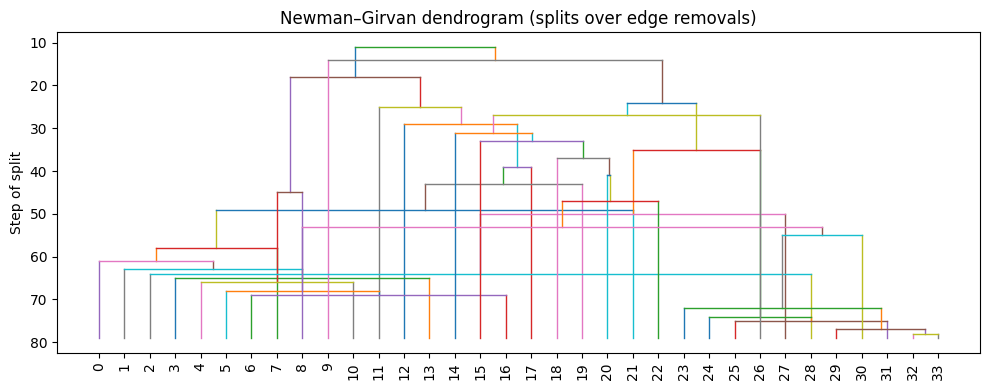

In [38]:
def assign_leaf_x(root, leaf_order):
    x_pos = {n: i for i, n in enumerate(leaf_order)}

    def rec(node):
        if node.left is None and node.right is None:
            xs = [x_pos[n] for n in node.members]
            node.x = float(np.mean(xs)) if xs else 0.0
            return node.x

        xL = rec(node.left) if node.left else 0.0
        xR = rec(node.right) if node.right else 0.0
        node.x = (xL + xR) / 2.0
        return node.x

    rec(root)

def set_heights(root, default_leaf_height):
    def rec(node):
        if node.left is None and node.right is None:
            node.h = default_leaf_height
            return
        node.h = node.split_step if node.split_step is not None else default_leaf_height
        if node.left:
            rec(node.left)
        if node.right:
            rec(node.right)
    rec(root)

def plot_dendrogram(root, leaf_order, max_step):
    assign_leaf_x(root, leaf_order)
    set_heights(root, default_leaf_height=max_step + 1)

    plt.figure(figsize=(10, 4))
    ax = plt.gca()

    def rec(node):
        if node.left is None or node.right is None:
            return

        ax.plot([node.left.x, node.left.x], [node.left.h, node.h], linewidth=1)
        ax.plot([node.right.x, node.right.x], [node.right.h, node.h], linewidth=1)
        ax.plot([node.left.x, node.right.x], [node.h, node.h], linewidth=1)

        rec(node.left)
        rec(node.right)

    rec(root)

    ax.set_xticks(range(len(leaf_order)))
    ax.set_xticklabels(leaf_order, rotation=90)
    ax.set_ylabel("Step of split")
    ax.set_title("Newman–Girvan dendrogram (splits over edge removals)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

leaf_order = sorted(list(set().union(*partitions[0])))
plot_dendrogram(root, leaf_order, max_step=int(df_ng["step"].max()))


#### Result analysis

- The dendrogram summarizes the hierarchy of community splits during edge removals.
- Earlier splits correspond to major community separation, while later splits refine smaller groups.


### Visualizing the best partition

We visualize the Karate Club graph with nodes colored by the maximum-modularity partition.


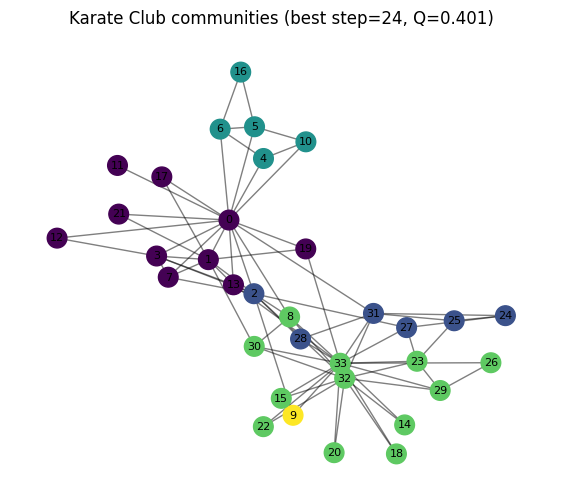

[10, 6, 5, 12, 1]

In [39]:
best_partition = partitions[best_step]
node_color = {}
for i, c in enumerate(best_partition):
    for n in c:
        node_color[n] = i

G_karate = nx.karate_club_graph()
pos = nx.spring_layout(G_karate, seed=42)

plt.figure(figsize=(7, 6))
nx.draw_networkx_nodes(G_karate, pos, node_size=200, node_color=[node_color[n] for n in G_karate.nodes()])
nx.draw_networkx_edges(G_karate, pos, alpha=0.5)
nx.draw_networkx_labels(G_karate, pos, font_size=8)
plt.title(f"Karate Club communities (best step={best_step}, Q={best_Q:.3f})")
plt.axis("off")
plt.show()

[len(c) for c in best_partition]


#### Final result analysis

- The selected partition maximizes modularity among the tested removal steps.
- The community sizes are reported in the final output above.
- This completes the manual Newman–Girvan implementation with step-by-step edge removal, modularity tracking, and dendrogram visualization.
